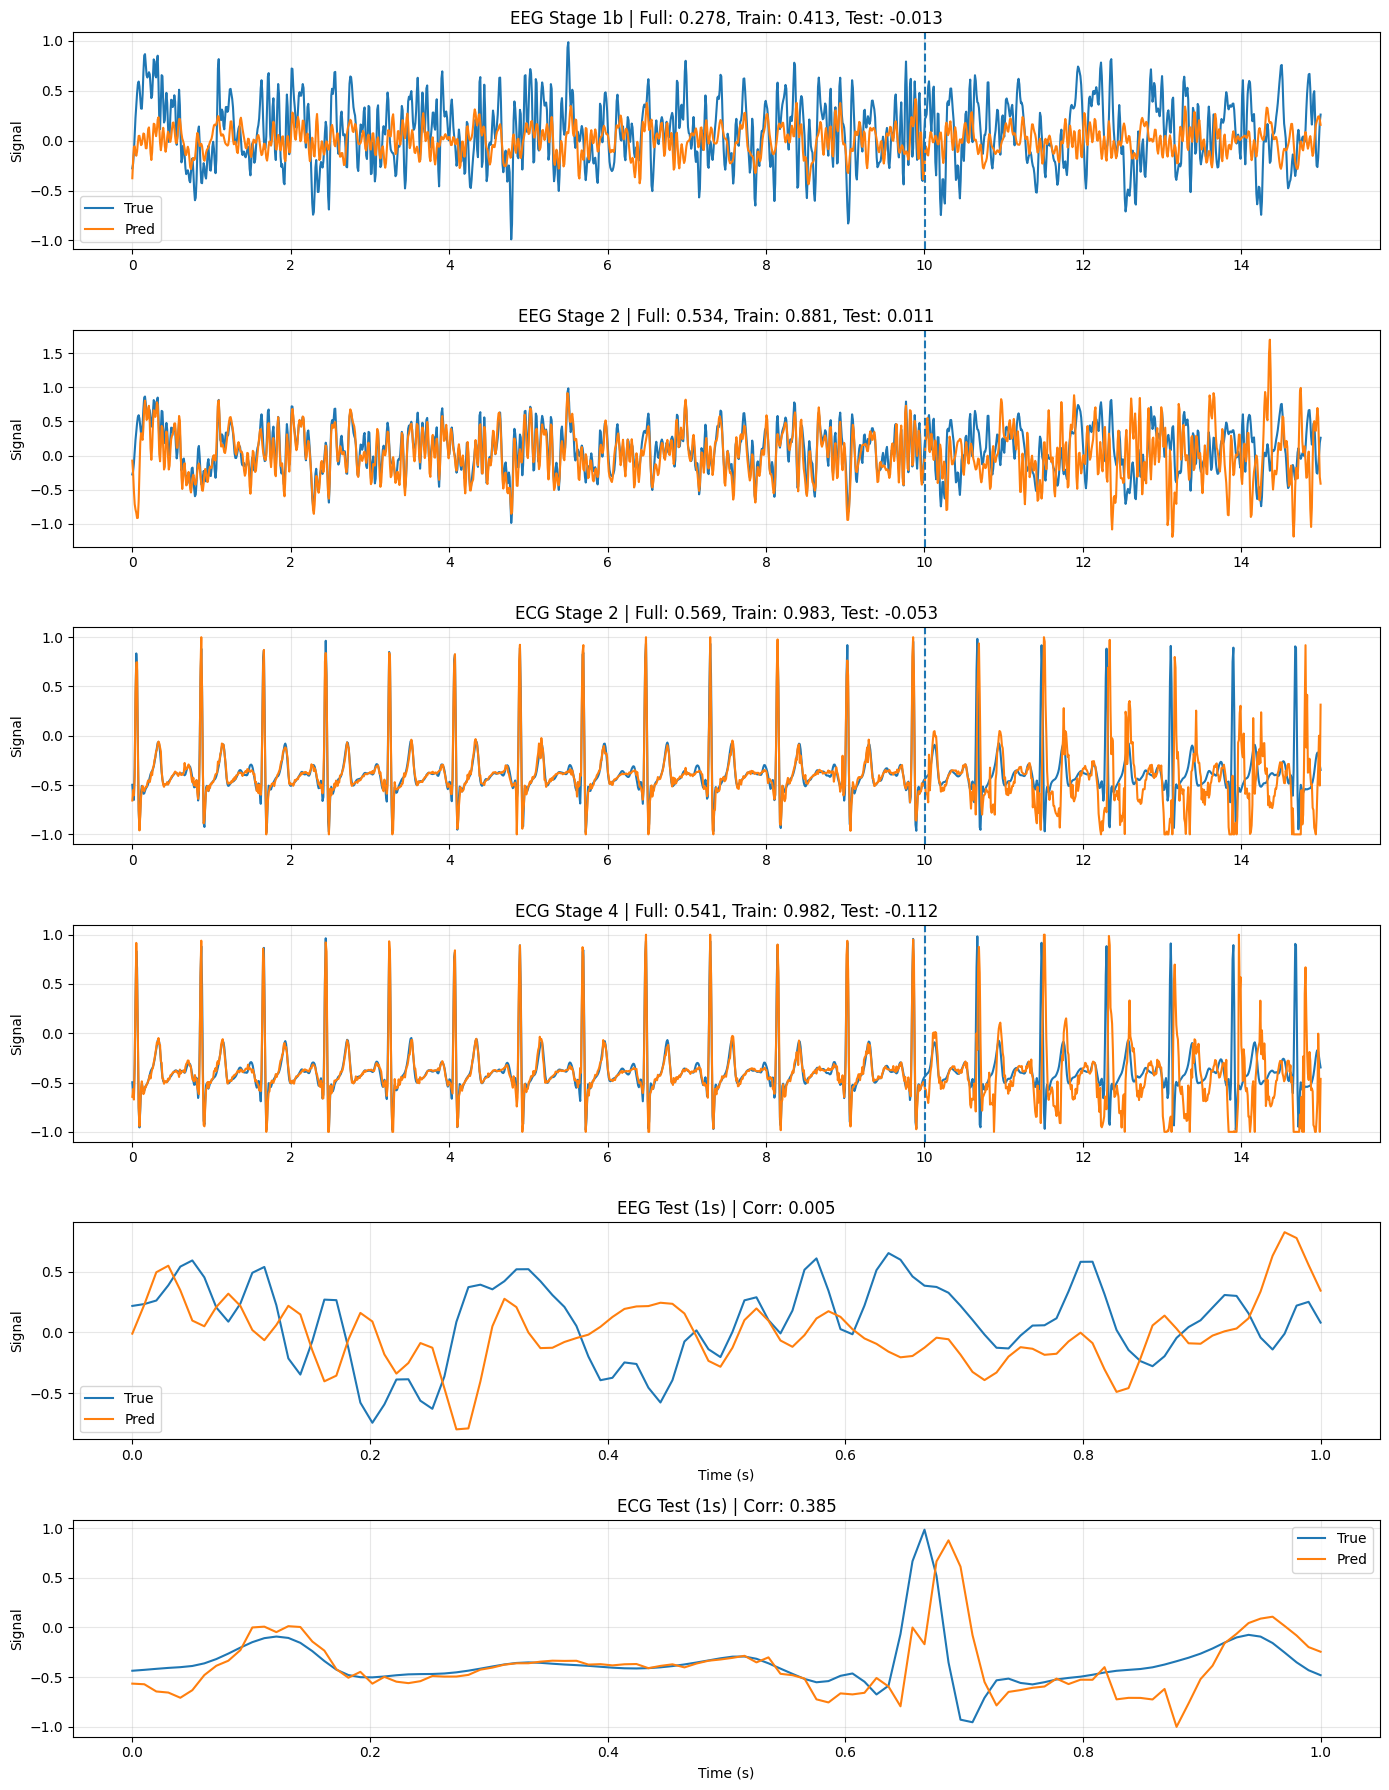

In [1]:
import numpy as np
import matplotlib.pyplot as plt

FS = 100  # sampling frequency


def compute_corr(x, y):
    x = x - np.mean(x)
    y = y - np.mean(y)
    return np.sum(x * y) / (np.sqrt(np.sum(x**2) * np.sum(y**2)) + 1e-8)


def load_all(region_dir, true_name, pred_name):
    return {
        "true_full": np.load(f"{region_dir}/{true_name}_full.npy"),
        "pred_full": np.load(f"{region_dir}/{pred_name}_full.npy"),
        "true_train": np.load(f"{region_dir}/{true_name}_train.npy"),
        "pred_train": np.load(f"{region_dir}/{pred_name}_train.npy"),
        "true_test": np.load(f"{region_dir}/{true_name}_test.npy"),
        "pred_test": np.load(f"{region_dir}/{pred_name}_test.npy"),
    }


def plot_all(region_dir):
    configs = [
        ("eeg_true", "eeg_stage1b", "EEG Stage 1b"),
        ("eeg_true", "eeg_stage2", "EEG Stage 2"),
        ("ecg_true", "ecg_stage2", "ECG Stage 2"),
        ("ecg_true", "ecg_stage4", "ECG Stage 4"),
    ]

    fig, axes = plt.subplots(6, 1, figsize=(14, 18))

    # -------- FULL PLOTS (same as before) --------
    for i, (true_name, pred_name, title) in enumerate(configs):
        data = load_all(region_dir, true_name, pred_name)

        true_full = data["true_full"]
        pred_full = data["pred_full"]
        true_train = data["true_train"]
        pred_train = data["pred_train"]
        true_test = data["true_test"]
        pred_test = data["pred_test"]

        # correlations
        corr_full = compute_corr(pred_full, true_full)
        corr_train = compute_corr(pred_train, true_train)
        corr_test = compute_corr(pred_test, true_test)

        # time
        T = len(true_full)
        t = np.linspace(0, T / FS, T)
        T_train = len(true_train)

        ax = axes[i]
        ax.plot(t, true_full, label="True")
        ax.plot(t, pred_full, label="Pred")

        ax.axvline(t[T_train], linestyle="--")

        ax.set_title(
            f"{title} | Full: {corr_full:.3f}, Train: {corr_train:.3f}, Test: {corr_test:.3f}"
        )
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)

        if i == 0:
            ax.legend()

    # -------- ZOOMED TEST PLOTS (1 second) --------
    zoom_configs = [
        ("eeg_true", "eeg_stage2", "EEG Test (1s)"),
        ("ecg_true", "ecg_stage4", "ECG Test (1s)"),
    ]

    for j, (true_name, pred_name, title) in enumerate(zoom_configs):
        data = load_all(region_dir, true_name, pred_name)

        true_test = data["true_test"]
        pred_test = data["pred_test"]

        # first 1 second
        n = min(FS, len(true_test))
        t = np.linspace(0, n / FS, n)

        corr = compute_corr(pred_test[:n], true_test[:n])

        ax = axes[4 + j]
        ax.plot(t, true_test[:n], label="True")
        ax.plot(t, pred_test[:n], label="Pred")

        ax.set_title(f"{title} | Corr: {corr:.3f}")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Run
region_dir = "/home/shobs/Desktop/DDP/multi_region_results/region_5"
plot_all(region_dir)